This notebook was generated by Claude Code.

Prompt: I have 01_eda.ipynb file. Can you conduct exploratory data analysis? The purpose is to analyze a/b test outcomes. For now, only use ab_test_df. ab_test_df = pd.read_excel('artea.xlsx',sheet_name='AB_test')

# 0. Configuration

In [1]:
# data frame
import pandas as pd
import numpy as np

# statistics
import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

# data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
ab_test_df = pd.read_excel('artea.xlsx', sheet_name='AB_test')
next_campaign_df = pd.read_excel('artea.xlsx', sheet_name='Next_Campaign')

# 1. Data Overview

In [3]:
print(f"Shape: {ab_test_df.shape}")
ab_test_df.head()

Shape: (5000, 10)


,id,trans_after,revenue_after,test_coupon,channel_acq,num_past_purch,spent_last_purchase,weeks_since_visit,browsing_minutes,shopping_cart
0,AB_1,0,0.00,0,2,6,62.99,6,1,0
1,AB_2,0,0.00,1,1,2,53.99,0,7,1
2,AB_3,0,0.00,1,2,3,88.98,3,4,0
3,AB_4,0,0.00,0,2,1,68.99,1,19,0
4,AB_5,0,0.00,1,3,3,66.49,4,20,0


In [4]:
ab_test_df.dtypes

id                      object
trans_after              int64
revenue_after          float64
test_coupon              int64
channel_acq              int64
num_past_purch           int64
spent_last_purchase    float64
weeks_since_visit        int64
browsing_minutes         int64
shopping_cart            int64
dtype: object

In [5]:
ab_test_df.describe()

,trans_after,revenue_after,test_coupon,channel_acq,num_past_purch,spent_last_purchase,weeks_since_visit,browsing_minutes,shopping_cart
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,0.14,7.66,0.50,2.07,2.06,57.42,3.22,13.69,0.29
std,0.42,23.63,0.50,1.05,2.56,55.47,2.26,6.96,0.46
min,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,0.00,0.00,0.00,1.00,0.00,0.00,1.00,9.00,0.00
50%,0.00,0.00,1.00,2.00,1.00,56.99,3.00,14.00,0.00
75%,0.00,0.00,1.00,3.00,3.00,73.99,5.00,19.00,1.00
max,5.00,247.96,1.00,5.00,22.00,361.96,7.00,37.00,1.00


In [6]:
# check for missing values
ab_test_df.isnull().sum()

id                     0
trans_after            0
revenue_after          0
test_coupon            0
channel_acq            0
num_past_purch         0
spent_last_purchase    0
weeks_since_visit      0
browsing_minutes       0
shopping_cart          0
dtype: int64

## Variable Descriptions
| Variable | Description |
|---|---|
| `id` | Unique customer identifier |
| `trans_after` | Number of transactions after coupon campaign (outcome) |
| `revenue_after` | Revenue generated after coupon campaign (outcome) |
| `test_coupon` | Treatment indicator: 1 = received coupon, 0 = no coupon |
| `channel_acq` | Acquisition channel (1-5) |
| `num_past_purch` | Number of past purchases |
| `spent_last_purchase` | Amount spent on last purchase |
| `weeks_since_visit` | Weeks since last visit (0-7) |
| `browsing_minutes` | Browsing time in minutes |
| `shopping_cart` | Shopping cart status: 1 = has items, 0 = empty |

# 2. Treatment vs Control Group Balance

## 2.1 Group Sizes

In [7]:
group_sizes = ab_test_df['test_coupon'].value_counts().rename({0: 'Control', 1: 'Treatment'})
print(group_sizes)
print(f"\nTreatment/Control ratio: {group_sizes['Treatment'] / group_sizes['Control']:.3f}")

test_coupon
Treatment    2502
Control      2498
Name: count, dtype: int64

Treatment/Control ratio: 1.002


## 2.2 Covariate Balance Check
Compare pre-treatment covariates between treatment and control groups to verify randomization.

In [8]:
covariates = ['channel_acq', 'num_past_purch', 'spent_last_purchase', 
              'weeks_since_visit', 'browsing_minutes', 'shopping_cart']

treatment = ab_test_df[ab_test_df['test_coupon'] == 1]
control = ab_test_df[ab_test_df['test_coupon'] == 0]

balance_records = []
for col in covariates:
    t_mean = treatment[col].mean()
    c_mean = control[col].mean()
    t_stat, p_val = ttest_ind(treatment[col], control[col])
    balance_records.append({
        'covariate': col,
        'treatment_mean': t_mean,
        'control_mean': c_mean,
        'difference': t_mean - c_mean,
        't_statistic': t_stat,
        'p_value': p_val,
        'balanced': '✓' if p_val > 0.05 else '✗'
    })

balance_df = pd.DataFrame(balance_records)
balance_df

,covariate,treatment_mean,control_mean,difference,t_statistic,p_value,balanced
0,channel_acq,2.07,2.06,0.01,0.33,0.74,✓
1,num_past_purch,2.09,2.02,0.07,0.99,0.32,✓
2,spent_last_purchase,58.16,56.69,1.47,0.93,0.35,✓
3,weeks_since_visit,3.26,3.18,0.07,1.16,0.25,✓
4,browsing_minutes,13.67,13.71,-0.04,-0.19,0.85,✓
5,shopping_cart,0.29,0.30,-0.01,-1.09,0.27,✓


# 3. Distribution of Outcome Variables

## 3.1 Transactions After Campaign (`trans_after`)

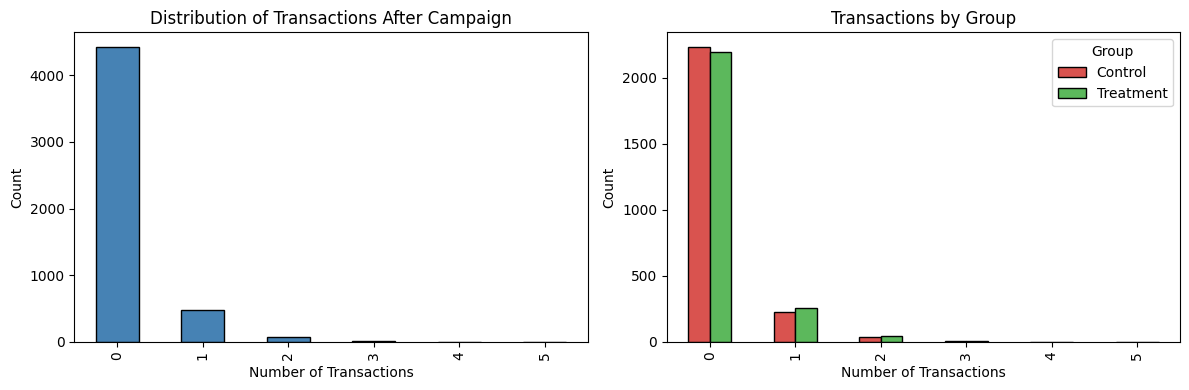

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# overall distribution
ab_test_df['trans_after'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Transactions After Campaign')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Count')

# by group
trans_by_group = ab_test_df.groupby('test_coupon')['trans_after'].value_counts().unstack(level=0).fillna(0)
trans_by_group.columns = ['Control', 'Treatment']
trans_by_group.plot(kind='bar', ax=axes[1], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[1].set_title('Transactions by Group')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('Count')
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()

In [10]:
# conversion rate (trans_after > 0)
ab_test_df['converted'] = (ab_test_df['trans_after'] > 0).astype(int)

conversion_rate = ab_test_df.groupby('test_coupon')['converted'].mean()
print("Conversion Rate (trans_after > 0):")
print(f"  Control:   {conversion_rate[0]:.4f} ({conversion_rate[0]*100:.2f}%)")
print(f"  Treatment: {conversion_rate[1]:.4f} ({conversion_rate[1]*100:.2f}%)")
print(f"  Lift:      {(conversion_rate[1] - conversion_rate[0]) / conversion_rate[0] * 100:.2f}%")

Conversion Rate (trans_after > 0):
  Control:   0.1069 (10.69%)
  Treatment: 0.1239 (12.39%)
  Lift:      15.92%


## 3.2 Revenue After Campaign (`revenue_after`)

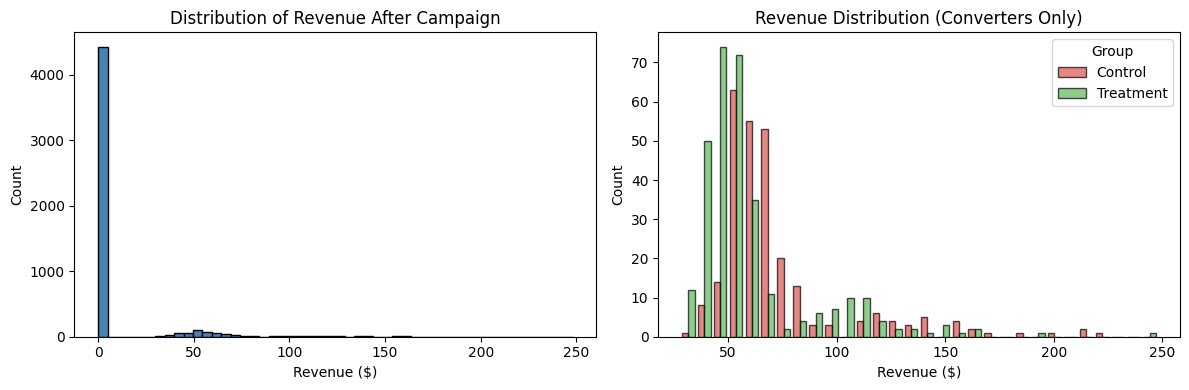

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# overall distribution (including zeros)
axes[0].hist(ab_test_df['revenue_after'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Revenue After Campaign')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Count')

# distribution for converters only (revenue > 0), by group
converters = ab_test_df[ab_test_df['revenue_after'] > 0]
axes[1].hist([converters[converters['test_coupon']==0]['revenue_after'], 
              converters[converters['test_coupon']==1]['revenue_after']], 
             bins=30, color=['#d9534f', '#5cb85c'], edgecolor='black', 
             label=['Control', 'Treatment'], alpha=0.7)
axes[1].set_title('Revenue Distribution (Converters Only)')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Count')
axes[1].legend(title='Group')

plt.tight_layout()
plt.show()

In [12]:
revenue_by_group = ab_test_df.groupby('test_coupon')['revenue_after'].agg(['mean', 'median', 'std', 'sum'])
revenue_by_group.index = ['Control', 'Treatment']
revenue_by_group.columns = ['Mean', 'Median', 'Std', 'Total']
revenue_by_group

,Mean,Median,Std,Total
Control,7.78,0.00,24.72,19434.86
Treatment,7.54,0.00,22.48,18861.76


# 4. Covariate Distributions

## 4.1 Continuous Covariates

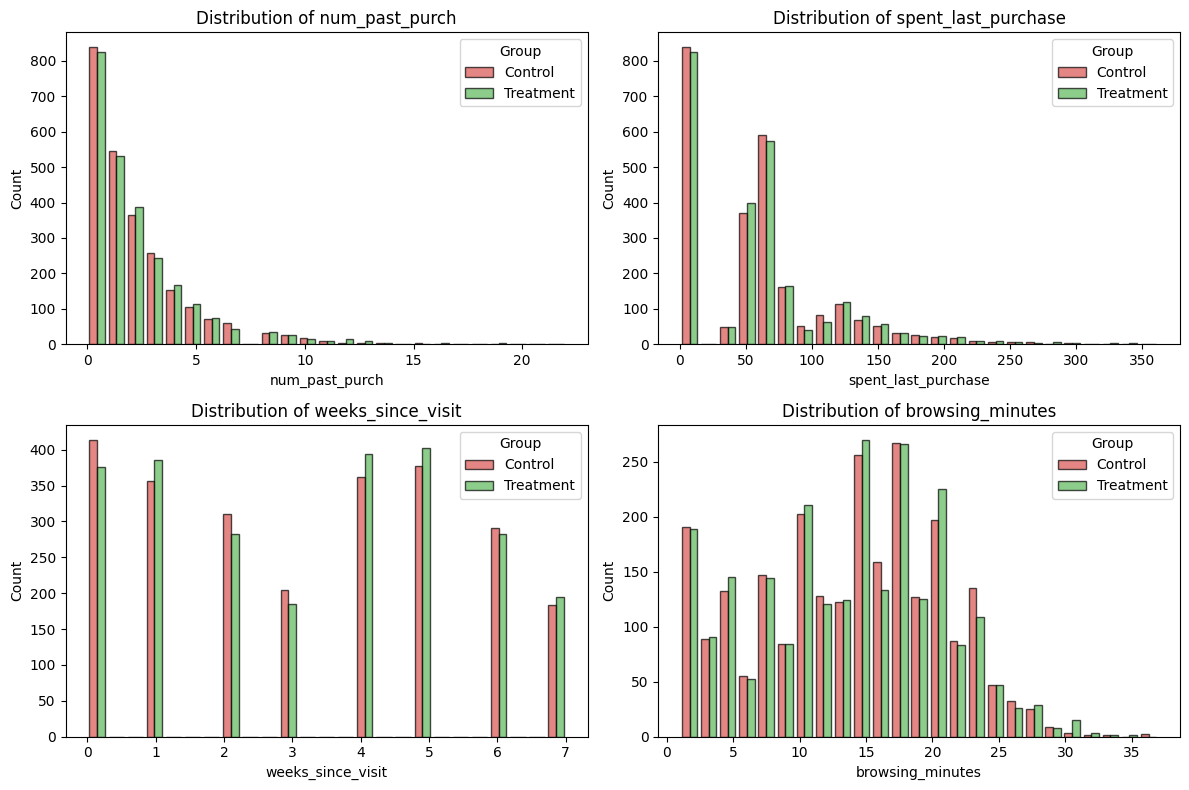

In [13]:
continuous_vars = ['num_past_purch', 'spent_last_purchase', 'weeks_since_visit', 'browsing_minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    axes[i].hist([control[col], treatment[col]], bins=25, 
                 color=['#d9534f', '#5cb85c'], edgecolor='black',
                 label=['Control', 'Treatment'], alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Group')

plt.tight_layout()
plt.show()

## 4.2 Categorical Covariates

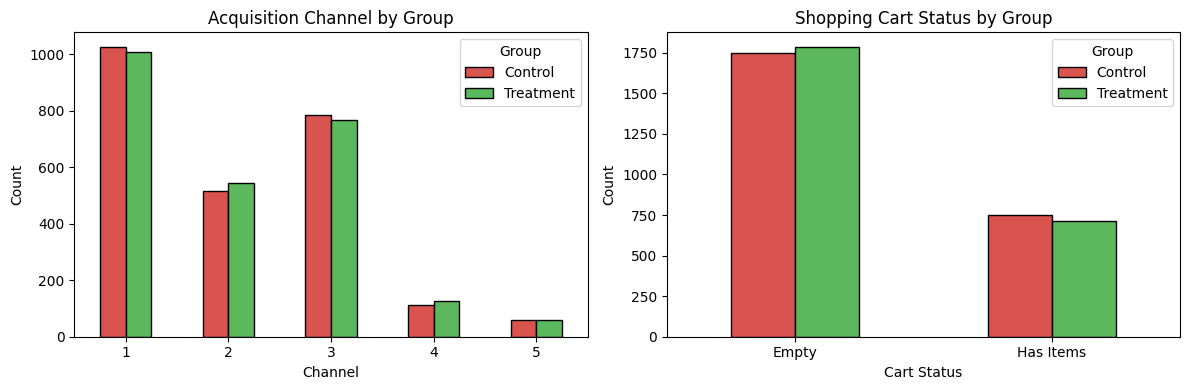

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# channel_acq by group
channel_ct = pd.crosstab(ab_test_df['channel_acq'], ab_test_df['test_coupon'])
channel_ct.columns = ['Control', 'Treatment']
channel_ct.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[0].set_title('Acquisition Channel by Group')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Count')
axes[0].legend(title='Group')
axes[0].tick_params(axis='x', rotation=0)

# shopping_cart by group
cart_ct = pd.crosstab(ab_test_df['shopping_cart'], ab_test_df['test_coupon'])
cart_ct.columns = ['Control', 'Treatment']
cart_ct.index = ['Empty', 'Has Items']
cart_ct.plot(kind='bar', ax=axes[1], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[1].set_title('Shopping Cart Status by Group')
axes[1].set_xlabel('Cart Status')
axes[1].set_ylabel('Count')
axes[1].legend(title='Group')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 5. Outcomes by Covariates

## 5.1 Conversion Rate by Acquisition Channel

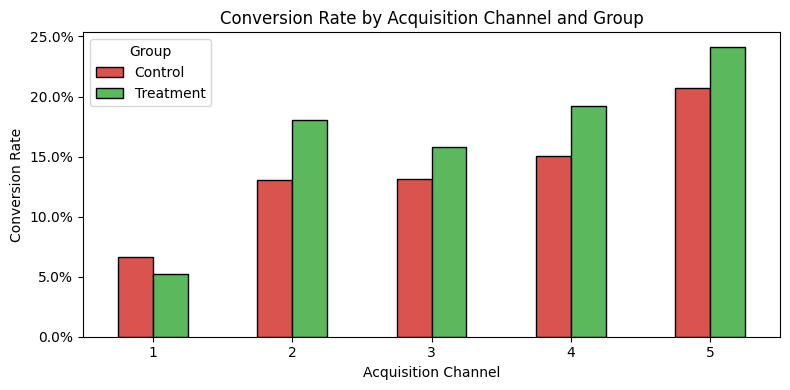

             Control  Treatment
channel_acq                    
1               0.07       0.05
2               0.13       0.18
3               0.13       0.16
4               0.15       0.19
5               0.21       0.24

Lift by channel:
  Channel 1: -20.6%
  Channel 2: +38.5%
  Channel 3: +20.2%
  Channel 4: +27.6%
  Channel 5: +16.7%


In [15]:
conv_by_channel = ab_test_df.groupby(['channel_acq', 'test_coupon'])['converted'].mean().unstack()
conv_by_channel.columns = ['Control', 'Treatment']

fig, ax = plt.subplots(figsize=(8, 4))
conv_by_channel.plot(kind='bar', ax=ax, color=['#d9534f', '#5cb85c'], edgecolor='black')
ax.set_title('Conversion Rate by Acquisition Channel and Group')
ax.set_xlabel('Acquisition Channel')
ax.set_ylabel('Conversion Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Group')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(conv_by_channel)
print(f"\nLift by channel:")
for ch in conv_by_channel.index:
    c, t = conv_by_channel.loc[ch, 'Control'], conv_by_channel.loc[ch, 'Treatment']
    lift = (t - c) / c * 100 if c > 0 else float('inf')
    print(f"  Channel {ch}: {lift:+.1f}%")

## 5.2 Conversion Rate by Shopping Cart Status

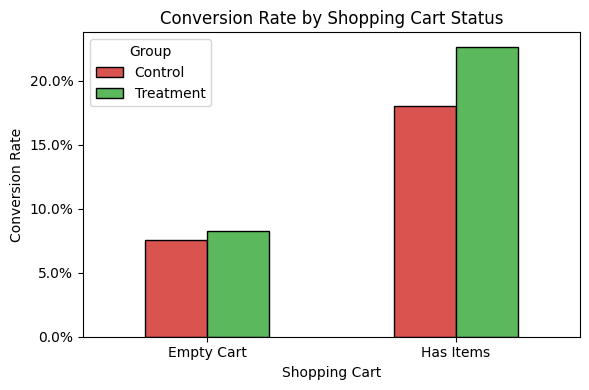

            Control  Treatment
Empty Cart     0.08       0.08
Has Items      0.18       0.23


In [16]:
conv_by_cart = ab_test_df.groupby(['shopping_cart', 'test_coupon'])['converted'].mean().unstack()
conv_by_cart.columns = ['Control', 'Treatment']
conv_by_cart.index = ['Empty Cart', 'Has Items']

fig, ax = plt.subplots(figsize=(6, 4))
conv_by_cart.plot(kind='bar', ax=ax, color=['#d9534f', '#5cb85c'], edgecolor='black')
ax.set_title('Conversion Rate by Shopping Cart Status')
ax.set_xlabel('Shopping Cart')
ax.set_ylabel('Conversion Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Group')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(conv_by_cart)

## 5.3 Mean Revenue by Covariates

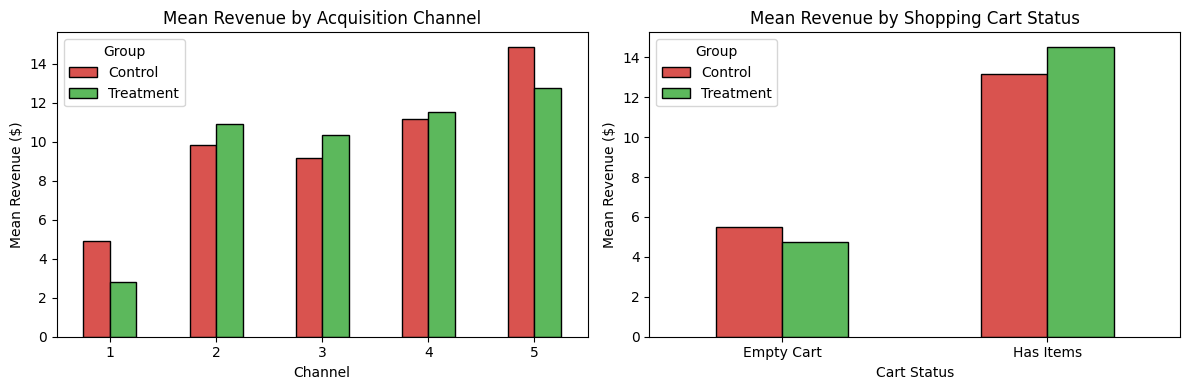

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# revenue by channel
rev_by_channel = ab_test_df.groupby(['channel_acq', 'test_coupon'])['revenue_after'].mean().unstack()
rev_by_channel.columns = ['Control', 'Treatment']
rev_by_channel.plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[0].set_title('Mean Revenue by Acquisition Channel')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Mean Revenue ($)')
axes[0].legend(title='Group')
axes[0].tick_params(axis='x', rotation=0)

# revenue by shopping cart
rev_by_cart = ab_test_df.groupby(['shopping_cart', 'test_coupon'])['revenue_after'].mean().unstack()
rev_by_cart.columns = ['Control', 'Treatment']
rev_by_cart.index = ['Empty Cart', 'Has Items']
rev_by_cart.plot(kind='bar', ax=axes[1], color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[1].set_title('Mean Revenue by Shopping Cart Status')
axes[1].set_xlabel('Cart Status')
axes[1].set_ylabel('Mean Revenue ($)')
axes[1].legend(title='Group')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 6. Correlation Analysis

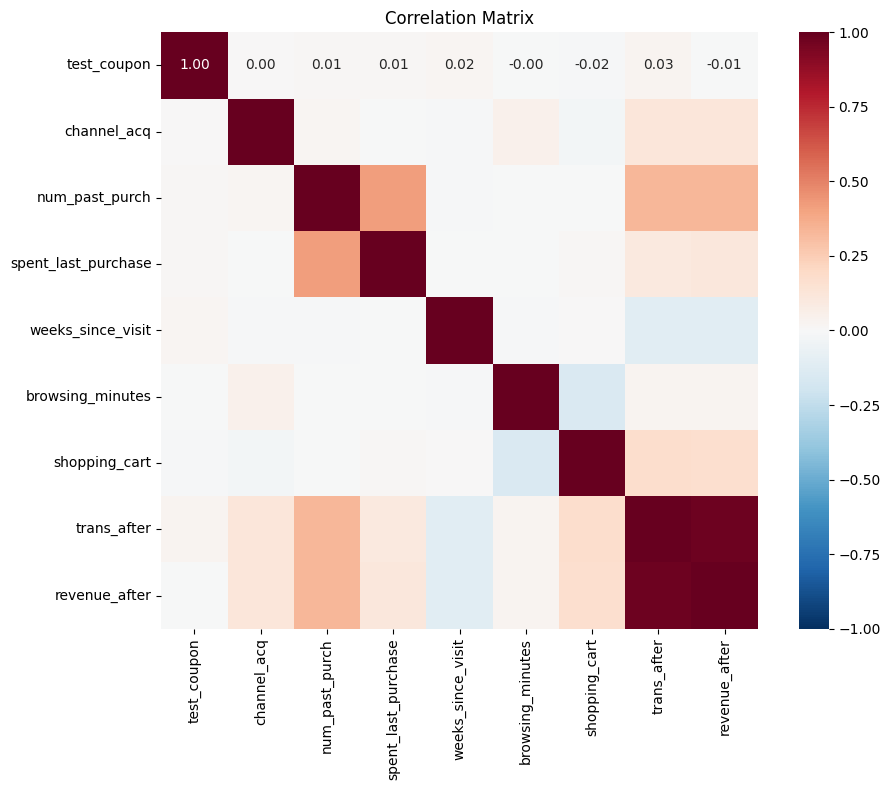

In [18]:
corr_cols = ['test_coupon', 'channel_acq', 'num_past_purch', 'spent_last_purchase', 
             'weeks_since_visit', 'browsing_minutes', 'shopping_cart', 'trans_after', 'revenue_after']

corr_matrix = ab_test_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 7. Summary Statistics by Group

In [19]:
summary_cols = ['trans_after', 'revenue_after', 'converted', 'num_past_purch', 
                'spent_last_purchase', 'weeks_since_visit', 'browsing_minutes', 'shopping_cart']

summary = ab_test_df.groupby('test_coupon')[summary_cols].agg(['mean', 'std']).T
summary.columns = ['Control', 'Treatment']
summary

Control  Treatment
trans_after         mean     0.13       0.15
                    std      0.39       0.44
revenue_after       mean     7.78       7.54
                    std     24.72      22.48
converted           mean     0.11       0.12
                    std      0.31       0.33
num_past_purch      mean     2.02       2.09
                    std      2.49       2.63
spent_last_purchase mean    56.69      58.16
                    std     54.35      56.56
weeks_since_visit   mean     3.18       3.26
                    std      2.26       2.25
browsing_minutes    mean    13.71      13.67
                    std      6.94       6.99
shopping_cart       mean     0.30       0.29
                    std      0.46       0.45